In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

sns.set_style("whitegrid")

df = pd.read_csv("/Users/hinahaq/Downloads/amz_uk_price_prediction_dataset.csv")
df.columns = df.columns.str.strip().str.lower()
df["price"] = pd.to_numeric(df["price"], errors="coerce")
df["stars"] = pd.to_numeric(df["stars"], errors="coerce")
df = df.dropna(subset=["price", "stars", "category"]).copy()

In [16]:
category_counts = df["category"].value_counts()


top_5 = category_counts.head(5)
print(top_5)

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Name: count, dtype: int64


/var/folders/xg/zchszbrn7h32p8rl8v_7dg4w0000gn/T/ipykernel_51585/270390865.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5.index, y=top_5.values, palette="viridis")


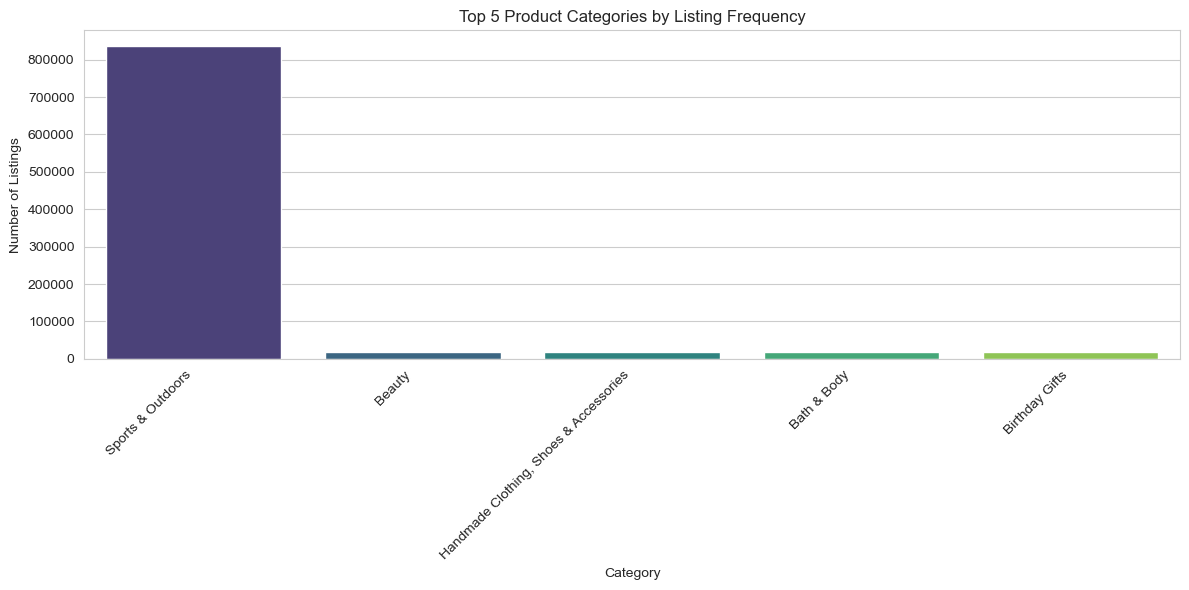

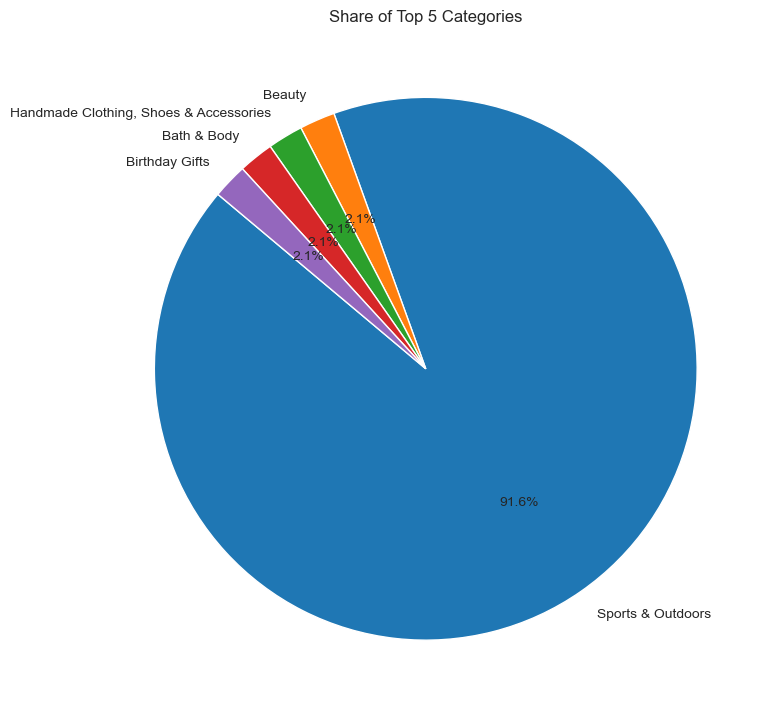

In [18]:
plt.figure(figsize=(12, 6))
sns.barplot(x=top_5.index, y=top_5.values, palette="viridis")
plt.title("Top 5 Product Categories by Listing Frequency")
plt.xlabel("Category")
plt.ylabel("Number of Listings")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 8))
plt.pie(top_5.values, labels=top_5.index, autopct="%1.1f%%", startangle=140)
plt.title("Share of Top 5 Categories")
plt.tight_layout()
plt.show()

## Part 1: Most Popular Product Categories

The Amazon UK listings are concentrated in a few product categories rather than spread evenly across all categories. The bar chart helps compare the most common categories, and the pie chart shows how much each top category contributes to the total.

Mean price: 89.24
Median price: 19.09
Mode price: 9.99
Variance: 119445.49
Standard deviation: 345.61
Range: 100000.00
Interquartile range: 36.00


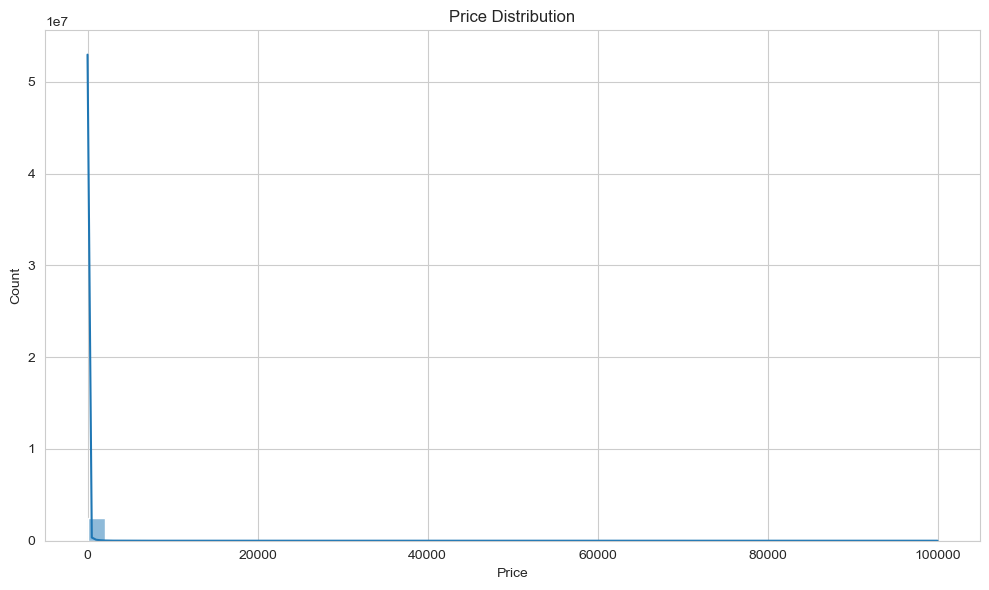

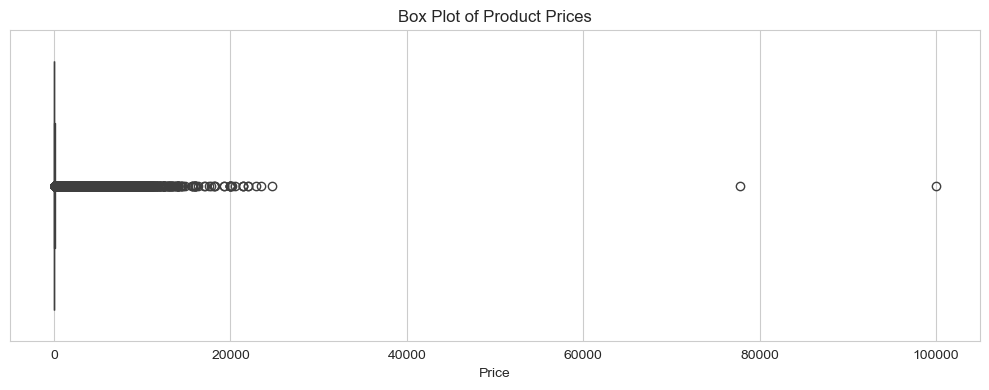

In [19]:
# Part 2: Pricing analysis
# Make sure price is numeric
df["price"] = pd.to_numeric(df["price"], errors="coerce")
price = df["price"].dropna()

# Measures of centrality
mean_price = price.mean()
median_price = price.median()
mode_price = price.mode().iloc[0]

print(f"Mean price: {mean_price:.2f}")
print(f"Median price: {median_price:.2f}")
print(f"Mode price: {mode_price:.2f}")

# Measures of dispersion
variance_price = price.var()
std_price = price.std()
range_price = price.max() - price.min()
iqr_price = price.quantile(0.75) - price.quantile(0.25)

print(f"Variance: {variance_price:.2f}")
print(f"Standard deviation: {std_price:.2f}")
print(f"Range: {range_price:.2f}")
print(f"Interquartile range: {iqr_price:.2f}")

# Histogram
plt.figure(figsize=(10, 6))
sns.histplot(price, bins=50, kde=True)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Box plot
plt.figure(figsize=(10, 4))
sns.boxplot(x=price)
plt.title("Box Plot of Product Prices")
plt.xlabel("Price")
plt.tight_layout()
plt.show()

“The price distribution is not perfectly balanced. Most products are clustered in a lower price range, but a smaller number of high-priced items stretch the distribution and create outliers.”

Top 10 categories:

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Manicure & Pedicure Products               18940
Skin Care                                  18769
Make-up                                    18756
Hair Care                                  18735
Fragrances                                 18564
Name: count, dtype: int64


/var/folders/xg/zchszbrn7h32p8rl8v_7dg4w0000gn/T/ipykernel_51585/2125729200.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_categories.index, y=top_10_categories.values, palette="viridis")


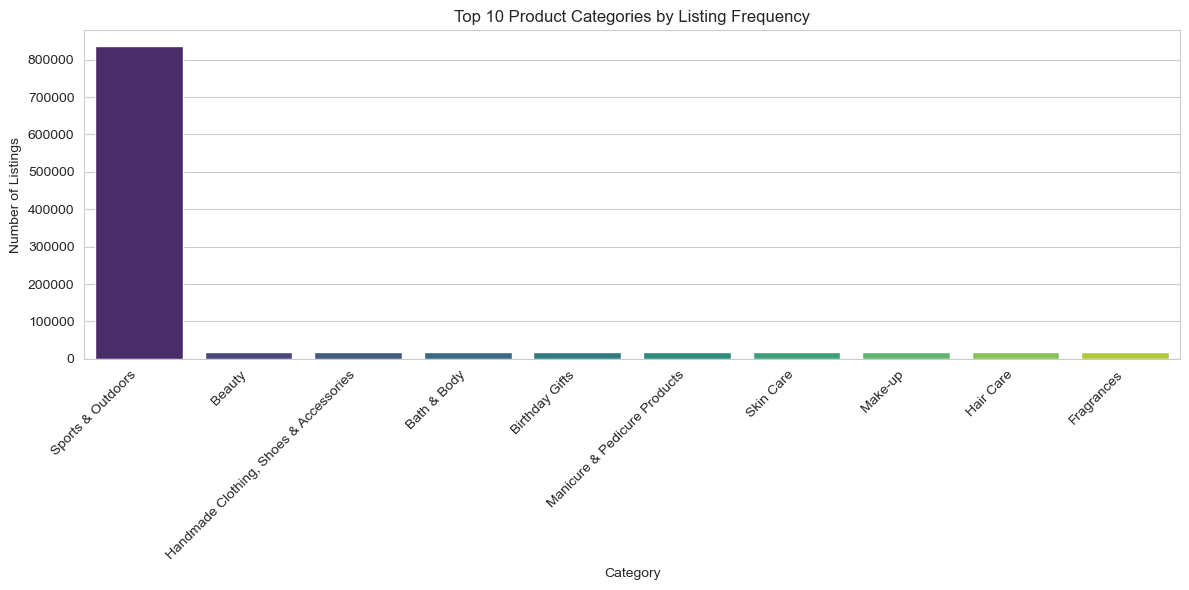

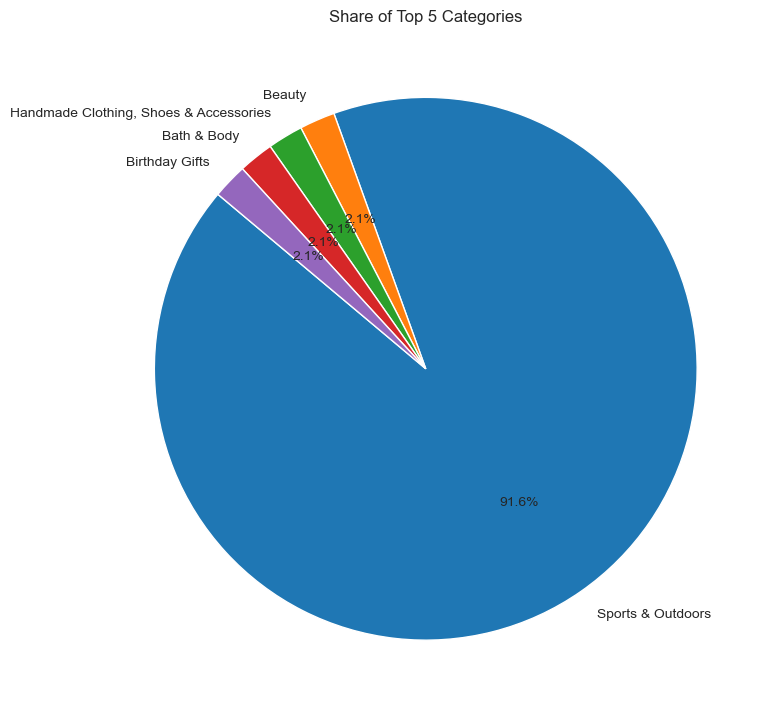


Ratings summary:

count    2.443651e+06
mean     2.152836e+00
std      2.194865e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      4.400000e+00
max      5.000000e+00
Name: stars, dtype: float64


In [20]:
# Part 3: Category counts and ratings

# Top 10 categories
category_counts = df["category"].value_counts()
top_10_categories = category_counts.head(10)
print("Top 10 categories:\n")
print(top_10_categories)

# Bar chart of top 10 categories
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_categories.index, y=top_10_categories.values, palette="viridis")
plt.title("Top 10 Product Categories by Listing Frequency")
plt.xlabel("Category")
plt.ylabel("Number of Listings")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Pie chart for top 5 categories
plt.figure(figsize=(8, 8))
plt.pie(
    category_counts.head(5).values,
    labels=category_counts.head(5).index,
    autopct="%1.1f%%",
    startangle=140
)
plt.title("Share of Top 5 Categories")
plt.tight_layout()
plt.show()

# Ratings summary
print("\nRatings summary:\n")
print(df["stars"].describe())

The category counts show which product groups appear most often in the dataset. The bar chart makes the differences between the most common categories easy to compare, while the pie chart shows how much each top category contributes to the total. The ratings summary shows whether customers generally score products highly or not

**Final business analysis**

The Amazon UK listings are concentrated in a small number of categories rather than spread evenly across all groups. The top 5 categories make up a large share of the dataset, which shows that a few product types dominate the marketplace.

Pricing is uneven and strongly right-skewed. The average price is pulled upward by expensive outliers, while the median and mode are lower, which means most products sit in a more affordable range and only a few items are priced very high.

The price spread is wide, which tells us that Amazon UK includes both low-cost and premium products. The histogram and box plot make this visible by showing a dense cluster of cheaper items and a long tail of unusually expensive ones.

Customer ratings are generally high and fairly consistent. That suggests that, despite the variation in price and category, the products in this dataset are usually well received by buyers.

Overall, the dataset suggests a marketplace with concentrated category demand, broad pricing tiers, and mostly positive customer feedback. 